# Simon-Style CBC-MAC Forgery

Recover the hidden relation and build a valid toy forgery.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))

from simon_qcrypto.attacks.cbc_mac.forgery_quantum import run

result = run(block_bits=3, seed=19, mode='statevector')
result


AttackResult(attack_name='cbc_mac_forgery', mode='statevector', success=True, query_count=2, recovered_relation='010', forgery={'queried_message': ['000', '000'], 'forged_message': ['001', '010'], 'tag': '000'}, metadata={'expected_delta': '010', 'expected_period': '1010', 'recovered_period': '1010'})

## Derived Simon circuit

Build the Simon instance induced by the CBC-MAC reduction and draw its circuit.

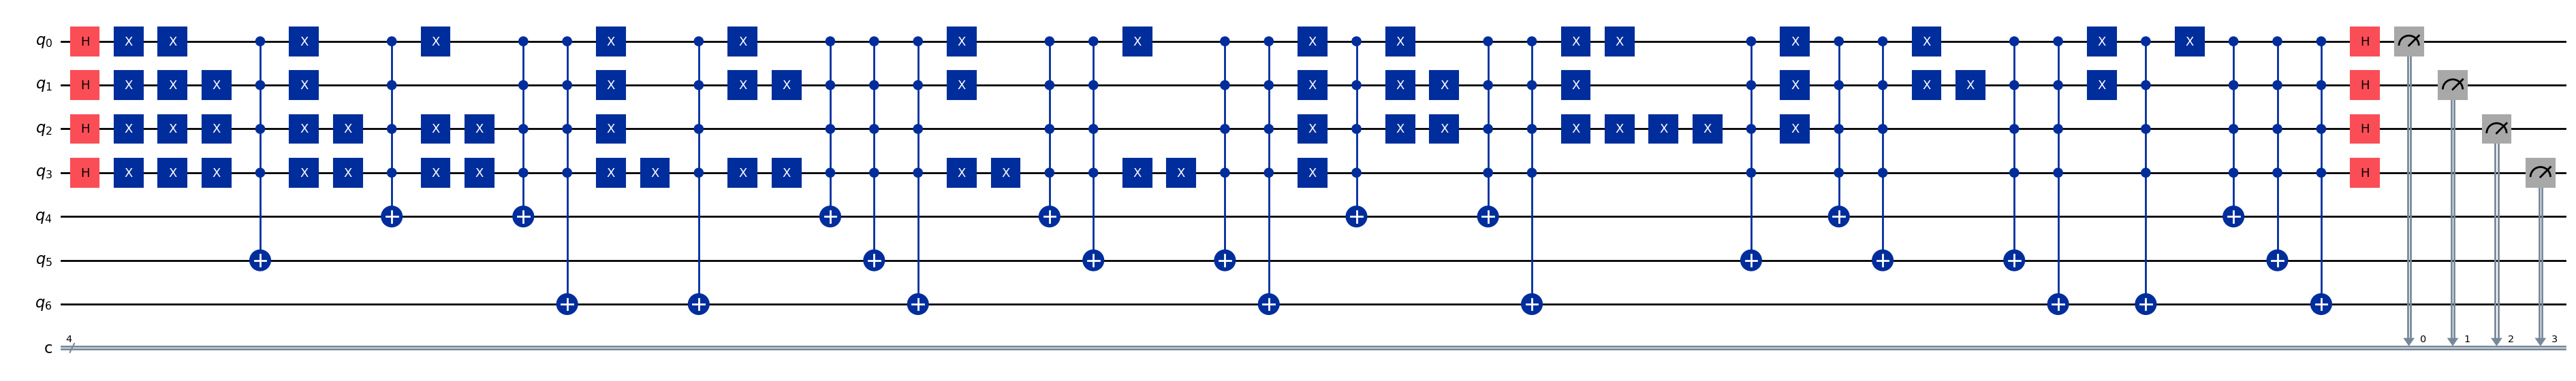

In [2]:
from simon_qcrypto.algorithms.simon.quantum import build_circuit
from simon_qcrypto.attacks.cbc_mac.oracle import build_oracle

oracle = build_oracle(block_bits=3, seed=19)
circuit = build_circuit(oracle.as_simon_problem(), measure=True)
circuit.draw('mpl', fold=-1, idle_wires=False)
